[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anderson-perez/IAC/blob/main/Aprendizado%20por%20Refor%C3%A7o/Aprendizado_por_Refor%C3%A7o_DQN_PPO.ipynb)

# Inteligência Artificial e Computacional

Segunda Parte da Disciplina

Informações:

* Prof. Anderson Luiz Fernandes Perez
* Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
* Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Aprendizado por Reforço (métodos não tabulares)

# Limitações dos Métodos Tabulares

Q-Learning e SARSA tabulares funcionam bem quando o número de estados e ações é pequeno.

Porém, em problemas reais, isso pode se tornar inviável.

Exemplos:

- robô móvel com posição contínua;
- imagens de câmera;
- leituras de LiDAR;
- velocidade, aceleração e orientação contínuas;
- ambiente dinâmico.

Nesses casos, a Q-Table fica enorme ou impossível de construir.

A solução é aproximar a função \(Q(s,a)\) usando modelos, como redes neurais.

# DQN — Deep Q-Network

O **DQN** substitui a Q-Table por uma rede neural.

Em vez de armazenar explicitamente:

$
Q(s,a)
$

em uma tabela, usa-se rede neural para aproximar essa função:

$
Q(s,a;\theta)
$

onde $\theta$ representa os pesos da rede neural.

## Ideia básica

Entrada:

$$
s
$$

Saída:

$$
Q(s,a_1), Q(s,a_2), ..., Q(s,a_n)
$$

A rede recebe o estado e retorna o valor estimado para cada ação possível.



## Visão Geral do DQN

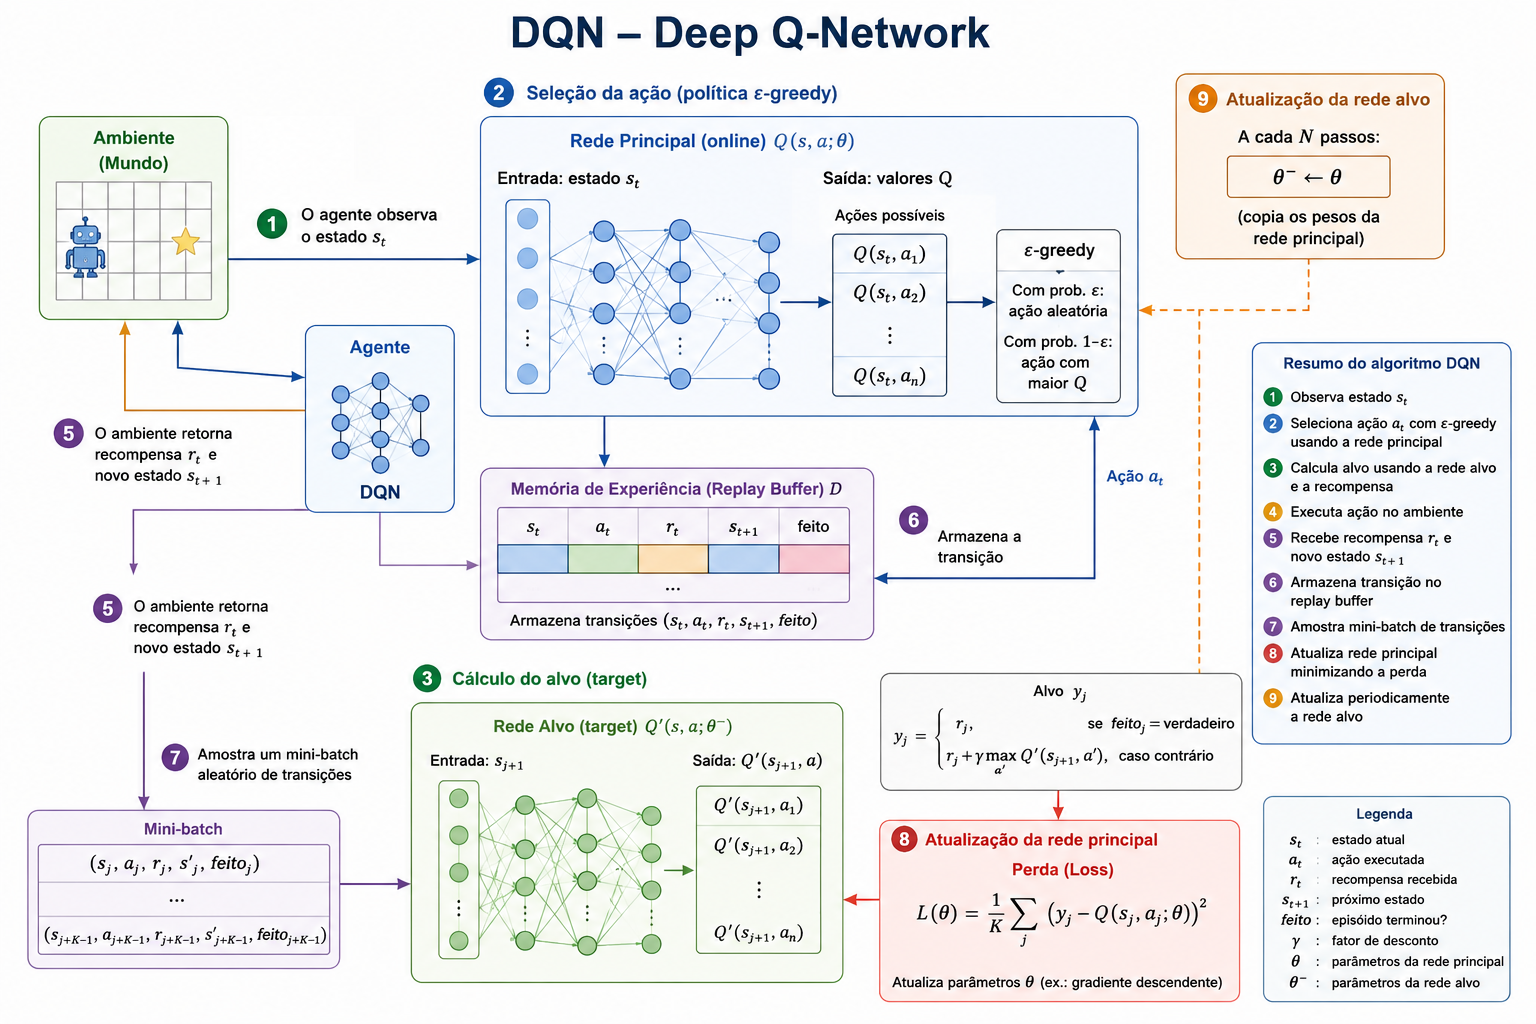

## Equações Base do DQN

A atualização clássica do Q-Learning é:

$$
Q(s_t,a_t) \leftarrow Q(s_t,a_t) + \alpha \left[ r_t + \gamma \max_{a'} Q(s_{t+1},a') - Q(s_t,a_t) \right]
$$

O termo:

$$
r_t + \gamma \max_{a'} Q(s_{t+1},a')
$$

é chamado de **alvo temporal** ou **TD target**.

O erro:

$$
\delta_t = r_t + \gamma \max_{a'} Q(s_{t+1},a') - Q(s_t,a_t)
$$

é o **erro de diferença temporal**.

No DQN, em vez de atualizar diretamente uma tabela, o erro é minimizado entre a predição da rede neural e o alvo temporal.

## Função de Perda

A função de perda do DQN pode ser escrita como:

$$
L(\theta) =
\mathbb{E}
\left[
\left(
y_t - Q(s_t,a_t;\theta)
\right)^2
\right]
$$

em que:

$$
y_t = r_t + \gamma \max_{a'} Q(s_{t+1},a';\theta^-)
$$

$\theta$ representa os pesos da rede principal e $\theta^-$ os pesos da **rede-alvo**.



### Por que usar uma rede-alvo?

Se a mesma rede neural fosse usada para calcular a predição e o alvo, o alvo mudaria a cada atualização. Isso torna o treinamento instável.

Por isso, o DQN usa duas redes:

- **rede principal:** atualizada frequentemente por gradiente;
- **rede-alvo:** atualizada mais lentamente.

Essa estratégia estabiliza o aprendizado.

## Técnicas importantes no DQN

- **Replay Buffer**: armazena experiências passadas e treina com amostras aleatórias;
- **Target Network**: usa uma rede alvo para estabilizar os alvos de treinamento;
- **Gradient Clipping**: limita gradientes muito grandes.

## DQN é Recomendado nas Seguintes Situações

- espaço de ações discreto;
- observações vetoriais ou imagens;
- problemas em que uma Q-Table seria inviável.

# Biblioteca Stable-Baselines3

A biblioteca `stable-baselines3` fornece implementações de algoritmos de aprendizado por reforço usando PyTorch.

Entre os algoritmos disponíveis estão:

- A2C;
- DQN;
- PPO;
- SAC;
- TD3;
- DDPG.

## DQN com Stable-Baselines3

Exemplo: ambiente `CartPole-v1`.

O objetivo é equilibrar uma haste sobre um carrinho.

Ações possíveis:

- mover para a esquerda;
- mover para a direita.

In [ ]:
!pip install stable_baselines3

In [ ]:
import stable_baselines3
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.evaluation import evaluate_policy

In [4]:
import gymnasium as gym

## Exemplo CartPole-V1

O objetivo é manter uma haste equilibrada sobre um carrinho. O agente pode aplicar força para a esquerda ou para a direita.

### Espaço de observação

O estado possui quatro variáveis:

1. posição do carrinho;
2. velocidade do carrinho;
3. ângulo da haste;
4. velocidade angular da haste.

### Espaço de ações

O agente tem duas ações discretas:

- `0`: empurrar para a esquerda;
- `1`: empurrar para a direita.



## Agente com DQN (aprendizado)

In [ ]:
env_dqn = gym.make("CartPole-v1")

modelo_dqn = DQN(
    policy="MlpPolicy",
    env=env_dqn,
    learning_rate=1e-3,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=32,
    gamma=0.99,
    exploration_fraction=0.2,
    exploration_final_eps=0.05,
    verbose=1
)

modelo_dqn.learn(total_timesteps=20000)

## Definição dos Parâmetros

Parâmetros importantes:

- `learning_rate`: taxa de aprendizado da rede neural;
- `buffer_size`: tamanho do replay buffer;
- `learning_starts`: número de passos antes de iniciar o treinamento;
- `batch_size`: tamanho do lote amostrado do replay buffer;
- `gamma`: fator de desconto;
- `exploration_fraction`: fração do treinamento em que $\epsilon$ decai;
- `exploration_final_eps`: valor final de $\epsilon$ na política $\epsilon$-greedy;
- `target_update_interval`: frequência de atualização da rede-alvo.


## Avaliação do DQN Após o Treinamento

A função `evaluate_policy` executa vários episódios e calcula a recompensa média.

In [6]:
resultado_dqn = evaluate_policy(
    modelo_dqn,
    env_dqn,
    n_eval_episodes=10
)

print("DQN - Recompensa média:", resultado_dqn[0])
print("DQN - Desvio padrão:", resultado_dqn[1])

DQN - Recompensa média: 9.5
DQN - Desvio padrão: 0.6708203932499369


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


## Execução do Agente com DQN

In [ ]:
obs, info = env_dqn.reset()

for i in range(20):
    action, _states = modelo_dqn.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_dqn.step(action)

    print(f"(DQN) -> Passo {i+1} | Ação: {action} | Recompensa: {reward}")

    if terminated or truncated:
        obs, info = env_dqn.reset()

# PPO — Proximal Policy Optimization

O **PPO** é um algoritmo de aprendizado por reforço profundo. Diferentemente do DQN, que aprende uma função de valor-ação, o PPO aprende diretamente uma política:

$$
\pi_\theta(a|s)
$$

O modelo aprende a probabilidade de escolher cada ação dado um estado.



## Ideia central

O PPO tenta melhorar a política gradualmente, evitando atualizações muito grandes.

Por isso, ele usa uma função objetivo com limitação, conhecida como **clipped objective**.

A ideia melhorar a política, mas sem mudar demais de uma vez.



## Visão Geral do PPO

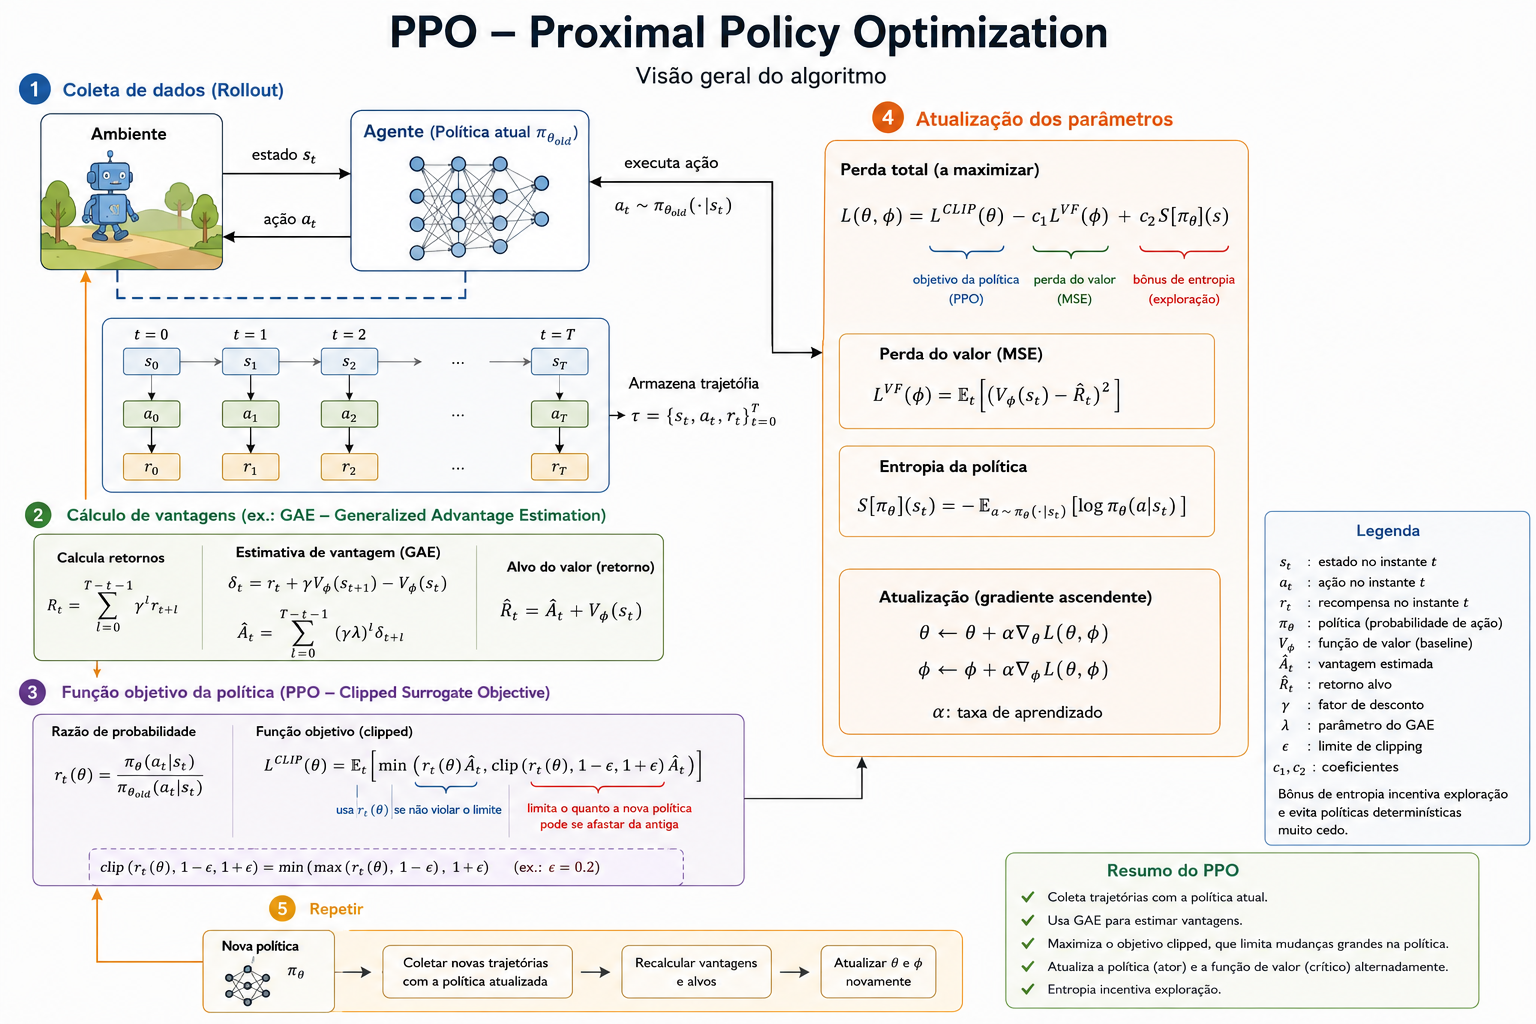

## Equações Base do PPO

O PPO é um algoritmo de Aprendizado por Reforço Profundo baseado em política.

Ele pertence à família dos métodos **Actor-Critic**.

### Actor

O **actor** representa a política:

$$
\pi_\theta(a|s)
$$

Ele decide quais ações devem ser tomadas.

### Critic

O **critic** estima o valor de um estado:

$$
V(s)
$$

Ele avalia o quão bom é estar naquele estado.

Portanto, o PPO aprende simultaneamente:

1. uma política para escolher ações;
2. uma função de valor para avaliar estados.

Métodos de gradiente de política podem sofrer com atualizações muito grandes.

Uma atualização muito agressiva pode destruir uma política que estava funcionando razoavelmente bem.

O PPO tenta evitar isso impondo uma restrição suave: a nova política não deve ficar muito distante da política anterior.

Por isso o nome:

**Proximal Policy Optimization**  
ou seja, otimização de política mantendo a nova política próxima da anterior.

## Razão de Probabilidades no PPO

O PPO compara a política nova com a política antiga por meio da razão:

$$
r_t(\theta) =
\frac{\pi_\theta(a_t|s_t)}
{\pi_{\theta_{old}}(a_t|s_t)}
$$

Interpretação:

- se $r_t(\theta) = 1$, a nova política atribui a mesma probabilidade à ação;
- se $r_t(\theta) > 1$, a nova política aumentou a probabilidade daquela ação;
- se $r_t(\theta) < 1$, a nova política reduziu a probabilidade daquela ação.

O PPO usa a ideia de **vantagem**:

$$
A_t = Q(s_t,a_t) - V(s_t)
$$

A vantagem mede se uma ação foi melhor ou pior do que o esperado para aquele estado.

- Se $A_t > 0$, a ação foi melhor do que o esperado.
- Se $A_t < 0$, a ação foi pior do que o esperado.

A política deve aumentar a probabilidade de ações com vantagem positiva e diminuir a probabilidade de ações com vantagem negativa.


## Função Objetivo do PPO

O principal componente do PPO é a função objetivo com clipping:

$$
L^{CLIP}(\theta) =
\mathbb{E}_t
\left[
\min
\left(
r_t(\theta) A_t,
\text{clip}(r_t(\theta), 1 - \epsilon, 1 + \epsilon) A_t
\right)
\right]
$$

A função `clip` limita a razão de probabilidades ao intervalo:

$$
[1 - \epsilon, 1 + \epsilon]
$$

Por exemplo, se $\epsilon = 0.2$, a razão fica limitada entre:

$$
[0.8, 1.2]
$$

Isso impede que a nova política se afaste demais da política antiga em uma única atualização.

## Vantagens do PPO

- é relativamente estável;
- funciona com ações discretas e contínuas;
- é bastante utilizado como baseline;
- é simples de usar com `stable-baselines3`;
- pode ser aplicado em controle, robótica e jogos.



## Principais Diferenças entre DQN e PPO

| Critério | DQN | PPO |
|---|---|---|
| Tipo | Value-based | Policy-gradient / Actor-Critic |
| Ações | Discretas | Discretas e contínuas |
| Aprende | Função $(Q(s,a))$ | Política $(\pi(a))$ |
| Usa replay buffer | Sim | Não, tipicamente on-policy |
| Exemplo comum | CartPole, Atari discreto | Controle, robótica, jogos |

## Agente com PPO (aprendizado)

In [ ]:
env_ppo = gym.make("CartPole-v1")

modelo_ppo = PPO(
    policy="MlpPolicy",
    env=env_ppo,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    verbose=1
)

modelo_ppo.learn(total_timesteps=20000)

## Definição dos Parâmetros

Parâmetros importantes:

- `learning_rate`: taxa de aprendizado;
- `n_steps`: número de passos coletados antes de cada atualização;
- `batch_size`: tamanho dos mini-lotes;
- `n_epochs`: número de passagens sobre os dados coletados;
- `gamma`: fator de desconto;
- `gae_lambda`: parâmetro usado no cálculo da vantagem generalizada;
- `clip_range`: valor de $\epsilon$ usado no clipping;
- `ent_coef`: coeficiente de entropia, usado para estimular exploração.

## Avaliação do PPO Após o Treinamento

In [9]:
resultado_ppo = evaluate_policy(
    modelo_ppo,
    env_ppo,
    n_eval_episodes=10
)

print("PPO - Recompensa média:", resultado_ppo[0])
print("PPO - Desvio padrão:", resultado_ppo[1])

PPO - Recompensa média: 500.0
PPO - Desvio padrão: 0.0


## Execução do Agente com PPO

In [ ]:
obs, info = env_ppo.reset()

for i in range(20):
    action, _states = modelo_ppo.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_ppo.step(action)

    print(f"(PPO) -> Passo {i+1} | Ação: {action} | Recompensa: {reward}")

    if terminated or truncated:
        obs, info = env_ppo.reset()

# Comparação do DQN com o PPO

In [11]:
import matplotlib.pylab as plt

In [ ]:
nomes = ["DQN", "PPO"]
medias = [resultado_dqn[0], resultado_ppo[0]]
desvios = [resultado_dqn[1], resultado_ppo[1]]

plt.figure(figsize=(7, 5))
plt.bar(nomes, medias, yerr=desvios, capsize=5)
plt.title("Comparação entre DQN e PPO no CartPole-v1")
plt.ylabel("Recompensa média")
plt.grid(axis="y")
plt.show()

print("DQN:", resultado_dqn)
print("PPO:", resultado_ppo)

# Salvando e Carregando os Modelos

Com o StableBaselines3 é possível salvar e posteriormente carregas os modelos já treinados.

In [13]:
# Exemplo - salvando os modelos
modelo_dqn.save("modelo_dqn_cartpole")
modelo_ppo.save("modelo_ppo_cartpole")

In [ ]:
# Exemplo - Carregando os modelos
modelo_dqn_carregado = DQN.load("modelo_dqn_cartpole", env=env_dqn)
modelo_ppo_carregado = PPO.load("modelo_ppo_cartpole", env=env_ppo)

# Referências

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

# Créditos

* Imagens geradas pelo chatgpt.